# Logistic Regression — 10-class & 4-class 비교

Phase 9 실험: 단일 pitch 77-dim 입력으로 가장 단순한 선형 분류 모델 평가.

- **10-class** (architecture 비교 그룹): LR, LightGBM, MLP, RNN, Transformer
- **4-class** (MDP/DQN 호환 그룹): LR, LightGBM, MLP (Model B)

작성일: 2026-05-23

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUTPUT_DIR = Path('../outputs')

data_10 = np.load(OUTPUT_DIR / 'evaluation_lr_10cls.npz', allow_pickle=True)
data_4  = np.load(OUTPUT_DIR / 'evaluation_lr_4cls.npz',  allow_pickle=True)

cls10 = ['Ball','Strike','Single','Double','Triple','HomeRun','FieldOut','Strikeout','Walk','HitByPitch']
cls4  = ['Ball','Strike','Foul','InPlay']

print('=== 10-class ===')
print(f'Top-1: {float(data_10["top1"])*100:.1f}%  Top-3: {float(data_10["top3"])*100:.1f}%  CE: {float(data_10["ce"]):.4f}')
print('=== 4-class ===')
print(f'Top-1: {float(data_4["top1"])*100:.1f}%  Top-3: {float(data_4["top3"])*100:.1f}%  CE: {float(data_4["ce"]):.4f}')


=== 10-class ===
Top-1: 41.1%  Top-3: 86.2%  CE: 1.4612
=== 4-class ===
Top-1: 57.3%  Top-3: 95.0%  CE: 1.0224


## 1. 핵심 지표 요약

| 구분 | Top-1 | Top-3 | CE |
|------|-------|-------|----|
| **10-class** | 41.1% | 86.2% | 1.4612 |
| **4-class** | 57.3% | 95.0% | 1.0224 |

**10-class 결과 해석**: Top-1 41.1%는 Strike 다수 클래스 빈도(41.1%)와 일치.
per-class accuracy를 보면 Strike=100%, 나머지 0% — 모델이 항상 Strike를 예측.

이는 극심한 class imbalance(Strike 41% vs Triple 0.09%)에서 class weight 없는 LR이
최적 전략으로 majority class만 예측하는 것. 선형 분리도 불충분.

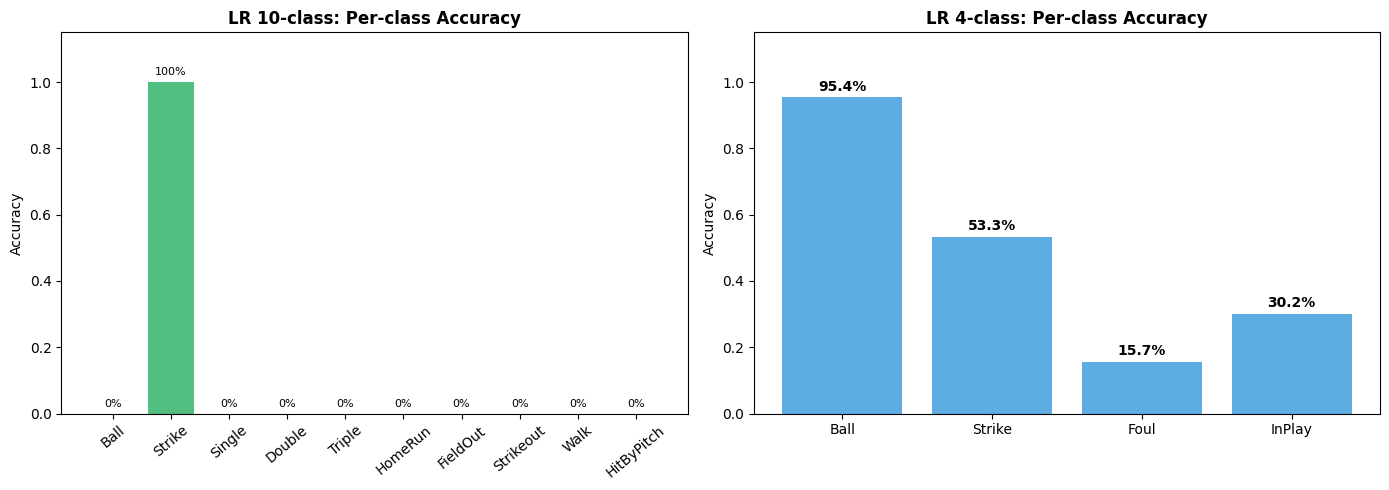

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 10-class per-class accuracy
acc10 = data_10['per_class_accuracy']
colors10 = ['#e74c3c' if a < 0.01 else '#f39c12' if a < 0.5 else '#27ae60' for a in acc10]
axes[0].bar(cls10, acc10, color=colors10, alpha=0.8)
axes[0].set_title('LR 10-class: Per-class Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis='x', rotation=40)
for i, v in enumerate(acc10):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=8)

# 4-class per-class accuracy
acc4 = data_4['per_class_accuracy']
colors4 = ['#3498db'] * 4
axes[1].bar(cls4, acc4, color=colors4, alpha=0.8)
axes[1].set_title('LR 4-class: Per-class Accuracy', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.15)
for i, v in enumerate(acc4):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 2. 분석

### 10-class 실패 원인
- **class imbalance**: Strike 41% vs Triple 0.09% (450배 차이)
- class weight 없는 cross-entropy → majority class 예측이 최적 전략
- 선형 경계로는 77-dim 단일 pitch에서 10개 pitch outcome 분리 불가

### 4-class 결과 (57.3%)
- 4개 클래스의 분포가 비교적 균등 (Ball 34%, Strike 27%, Foul 18%, InPlay 17%)
- Ball 95.4% 우수, Strike 53.3% 적정, Foul 15.7% 저조
- Foul은 Strike와 혼동 — 선형 경계의 한계

### 결론
LR은 4-class에서 57.3%로 유의미한 기준선을 제공하지만,
10-class 불균형 문제에서는 class weight 미적용 시 collapse.